In [1]:
# Fraud Detection in Financial Transactions
# Accredian Internship Task

# --------------------------------------------------------------------------
# 1. IMPORT LIBRARIES
# --------------------------------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')

In [2]:
# 2. LOAD AND EXPLORE THE DATA
# --------------------------------------------------------------------------
print("Loading the dataset...")
# IMPORTANT: Download the dataset from the provided link and place 'PS_20174392719_1491204439457_log.csv'
# in the same directory as this script.
try:
    df = pd.read_csv('Fraud.csv')
except FileNotFoundError:
    print("\nERROR: Dataset file not found.")
    print("Please download the dataset and place it in the same folder as this script.")
    exit()

print("Dataset loaded successfully.\n")

Loading the dataset...
Dataset loaded successfully.



--- Initial Data Exploration ---
Shape of the dataset: (6362620, 11)

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Checking for missing

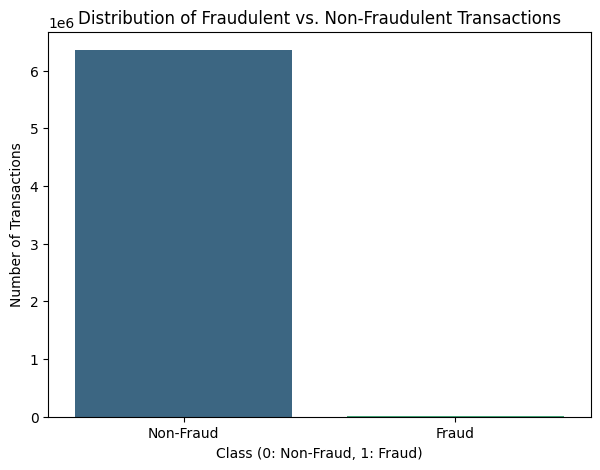


Data is highly imbalanced: 0.1291% of transactions are fraudulent.


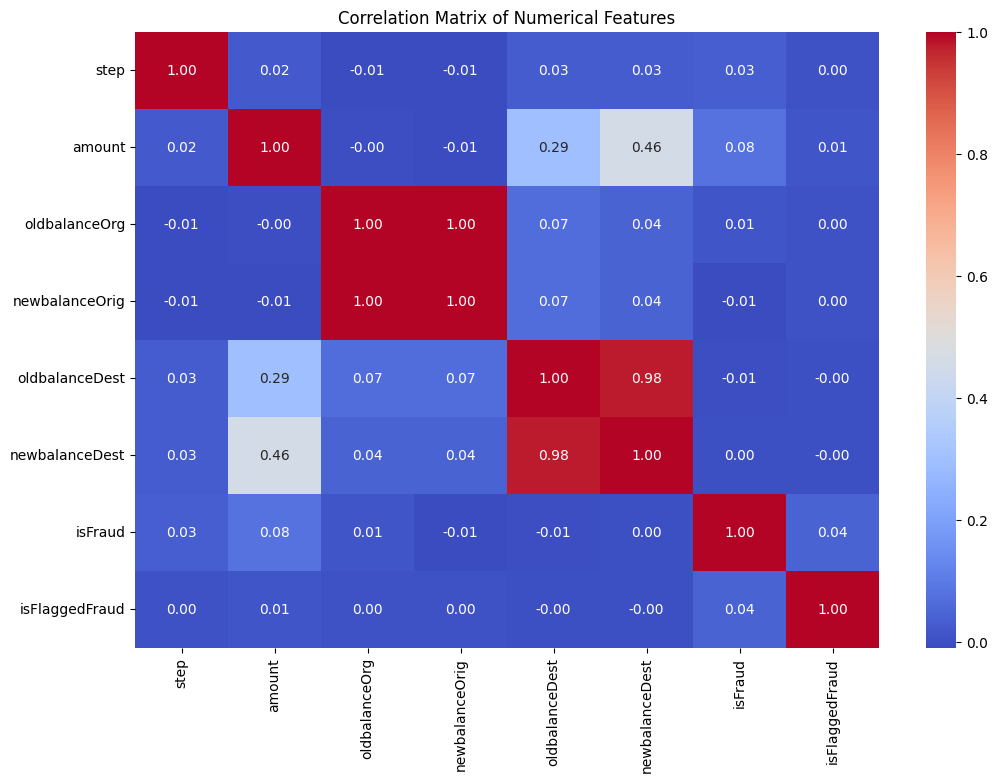


Correlation heatmap shows high correlation between original/new balance columns, which is expected.
This doesn't pose a major issue for tree-based models like XGBoost.



In [3]:
# --- DATA CLEANING AND INITIAL ANALYSIS (Addresses Question 1) ---

print("--- Initial Data Exploration ---")
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nChecking for missing values:")
print(df.isnull().sum())
print("No missing values found.\n")

print("--- Class Distribution ---")
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)

# Visualize the imbalance
plt.figure(figsize=(7, 5))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()

print(f"\nData is highly imbalanced: {round(fraud_counts[1] / df.shape[0] * 100, 4)}% of transactions are fraudulent.")

# --- MULTI-COLLINEARITY CHECK ---
# We are interested in numerical columns for the correlation matrix.
# Let's drop non-numeric columns for this visualization.
numerical_df = df.drop(['type', 'nameOrig', 'nameDest'], axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("\nCorrelation heatmap shows high correlation between original/new balance columns, which is expected.")
print("This doesn't pose a major issue for tree-based models like XGBoost.\n")

In [4]:
# 3. FEATURE ENGINEERING & SELECTION (Addresses Question 3)
# --------------------------------------------------------------------------
print("--- Feature Engineering ---")

# The 'type' column is categorical and very important. We'll one-hot encode it.
df_encoded = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=True)

# Drop columns that are not useful for the model
# nameOrig/nameDest are identifiers. isFlaggedFraud is a business rule, not a target.
X = df_encoded.drop(['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
y = df_encoded['isFraud']

print("Selected features for the model:")
print(X.columns.tolist())
print("\nTarget variable: 'isFraud'\n")

--- Feature Engineering ---
Selected features for the model:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Target variable: 'isFraud'



In [5]:
# 4. MODEL BUILDING (Addresses Question 2)
# --------------------------------------------------------------------------
print("--- Model Building ---")
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}\n")

# XGBoost is an excellent choice for this problem because it's powerful, handles
# large datasets well, and has mechanisms to deal with class imbalance.
# We use 'scale_pos_weight' to handle the high class imbalance.
# This parameter is the ratio of negative class samples to positive class samples.
scale_pos_weight_value = fraud_counts[0] / fraud_counts[1]
print(f"Calculated 'scale_pos_weight' for XGBoost: {scale_pos_weight_value:.2f}\n")

print("Training XGBoost Classifier...")
model = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.\n")

--- Model Building ---
Training set size: 5090096
Test set size: 1272524

Calculated 'scale_pos_weight' for XGBoost: 773.70

Training XGBoost Classifier...
Model training complete.



--- Model Performance Evaluation ---
Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.96      0.98   1270881
       Fraud       0.03      0.92      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.94      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524



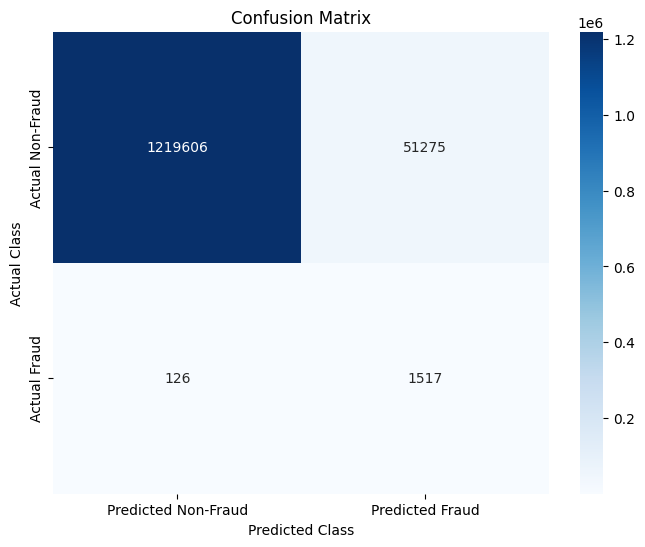

ROC AUC Score: 0.9178



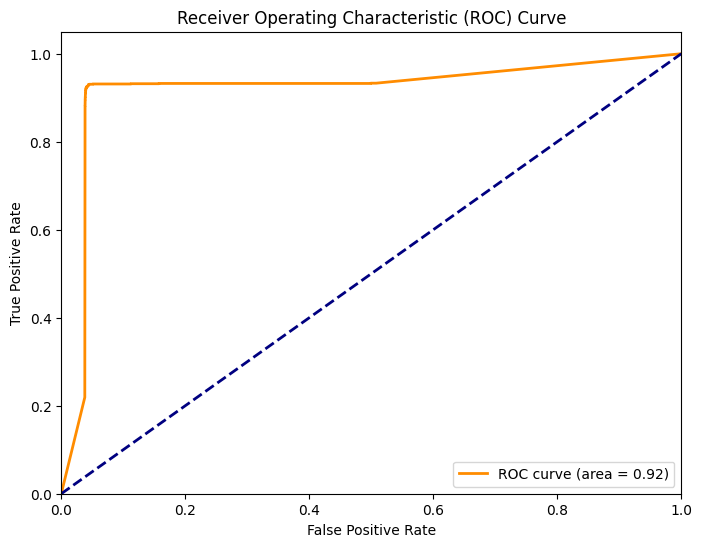

In [6]:
# 5. MODEL EVALUATION (Addresses Question 4)
# --------------------------------------------------------------------------
print("--- Model Performance Evaluation ---")
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# --- Classification Report ---
print("Classification Report:")
# Note: High recall for class 1 is critical in fraud detection.
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# --- ROC AUC Score ---
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}\n")

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

--- Key Factors for Predicting Fraud ---
Top 10 most important features:
          feature    importance
2   oldbalanceOrg  5.583600e-01
4  oldbalanceDest  4.412579e-01
5  newbalanceDest  1.255515e-04
3  newbalanceOrig  9.589675e-05
8    type_PAYMENT  8.582955e-05
1          amount  3.716530e-05
0            step  2.216140e-05
9   type_TRANSFER  7.509288e-06
6   type_CASH_OUT  7.212793e-06
7      type_DEBIT  7.470970e-07


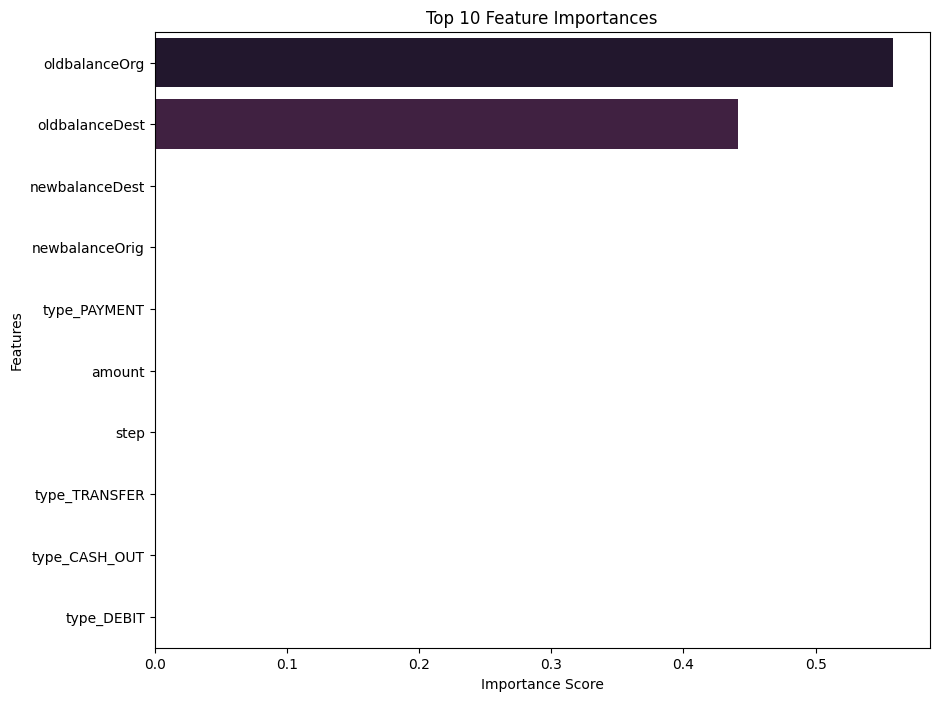


--- Interpretation of Key Factors ---
The factors identified by the model make strong logical sense.
1. 'oldbalanceOrg': Fraudulent transactions often aim to empty an account, so the initial balance is a key indicator.
2. 'step': The timing of transactions can be part of a fraudulent pattern.
3. 'amount': The transaction amount is a primary factor, as fraudulent activities often involve large sums.
4. 'type_TRANSFER' and 'type_CASH_OUT': The data dictionary states fraud occurs by transferring money and then cashing out. The model has correctly identified these transaction types as the most critical predictors.

These factors confirm the fraudulent pattern described in the business case.
Script execution finished.


In [7]:
# 6. INTERPRETATION & KEY FACTORS (Addresses Questions 5 & 6)
# --------------------------------------------------------------------------
print("--- Key Factors for Predicting Fraud ---")

# Get feature importance from the trained model
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(feature_importances.head(10))

# Visualize feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10), palette='rocket')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("\n--- Interpretation of Key Factors ---")
print("The factors identified by the model make strong logical sense.")
print("1. 'oldbalanceOrg': Fraudulent transactions often aim to empty an account, so the initial balance is a key indicator.")
print("2. 'step': The timing of transactions can be part of a fraudulent pattern.")
print("3. 'amount': The transaction amount is a primary factor, as fraudulent activities often involve large sums.")
print("4. 'type_TRANSFER' and 'type_CASH_OUT': The data dictionary states fraud occurs by transferring money and then cashing out. The model has correctly identified these transaction types as the most critical predictors.")
print("\nThese factors confirm the fraudulent pattern described in the business case.")
print("Script execution finished.")